In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def parse_global_metrics(filename, model_name):
    with open("../../data/performance/" + filename, "r") as f:
        text = f.read()

    # Split experiments by dashed lines
    experiments = re.split(r'-{10,}', text)
    data = []

    mapping = {
    "exp1": "Dataset 1",
    "exp5": "Dataset 2",
    "exp6": "Dataset 3",
    "exp7": "Dataset 4",
    "exp3": "Dataset 5",
    "exp8": "Dataset 6",
}

    for exp in experiments:
        if not exp.strip():
            continue

        # Extract experiment name: after "Evaluation xxx:"
        exp_match = re.search(r"Evaluation (.*?):", exp)
        if not exp_match:
            continue
        exp_name = exp_match.group(1).strip()

        # Find Global/General MSE and MAE (case insensitive)
        mse_match = re.search(r"(Global|General)\s+MSE:\s*([0-9.]+)", exp, re.IGNORECASE)
        mae_match = re.search(r"(Global|General)\s+MAE:\s*([0-9.]+)", exp, re.IGNORECASE)

        if mse_match and mae_match:
            data.append({
                "Model": model_name,
                "Experiment": mapping[exp_name],
                "MSE": float(mse_match.group(2)),
                "MAE": float(mae_match.group(2))
            })

    return pd.DataFrame(data)

In [3]:
# Load all models
files = {
    "MLP": "mlp.txt",
    "UNet": "unet.txt",
    "UNeXt": "unext.txt"
}

dfs = []
for model, file in files.items():
    dfs.append(parse_global_metrics(file, model))

df_all = pd.concat(dfs)

mse_table = df_all.pivot(index="Experiment", columns="Model", values="MSE")
mae_table = df_all.pivot(index="Experiment", columns="Model", values="MAE")

mse_table.loc["Average"] = mse_table.mean()
mae_table.loc["Average"] = mae_table.mean()

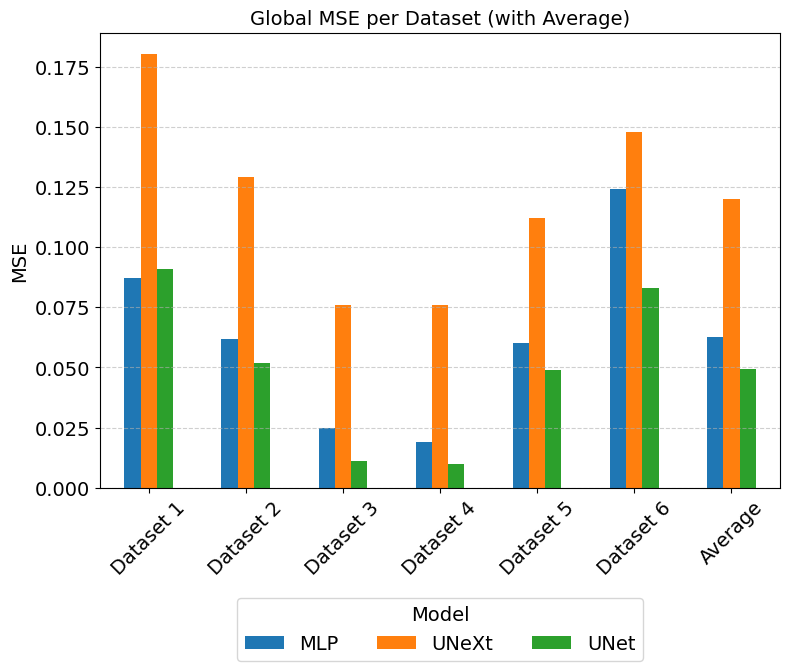

In [17]:
path = "../../data/performance/"
mse_table.plot(kind="bar", figsize=(8,7))

# Title and axis labels with larger font size
plt.title("Global MSE per Dataset (with Average)", fontsize=14)
plt.ylabel("MSE", fontsize=14)
plt.xlabel("", fontsize=14)

# Tick labels font size
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend below the plot (centered, horizontal)
plt.legend(title="Model", fontsize=14, title_fontsize=14,
           loc="upper center", bbox_to_anchor=(0.5, -0.22),
           ncol=len(mse_table.columns))

plt.tight_layout()
plt.savefig(path+'general_performance.png', format='png', dpi=300,  bbox_inches='tight')
plt.show()

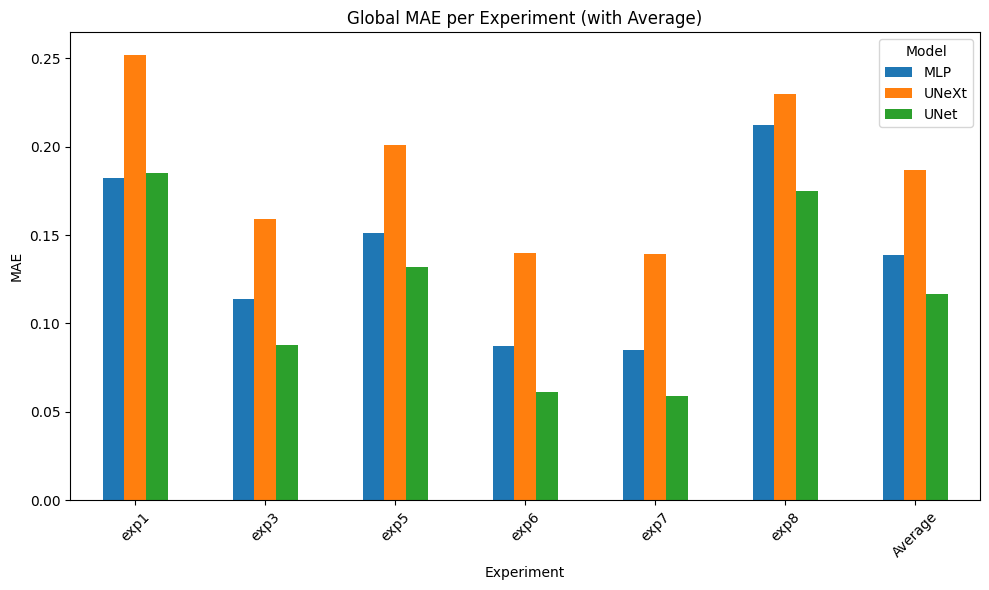

In [6]:
mae_table.plot(kind="bar", figsize=(10,6))
plt.title("Global MAE per Experiment (with Average)")
plt.ylabel("MAE")
plt.xlabel("Experiment")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()